# Предсказание атрибутов узлов с использованием графовых нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Курс "Машинное обучение на графах", Лекции 4-5 "Графовые нейронные сети"
* Документация:
    * https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html
    * https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.Planetoid.html
    * https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#convolutional-layers

## Вопросы для совместного обсуждения

1\. Обсудите основные шаги для решения задачи предсказания атрибутов узлов при помощи графовых нейронных сетей c использованием пакета `torch_geometric`.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from torch_geometric.datasets import Planetoid
import torch_geometric.nn as geom_nn
from torch_geometric.loader import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from typing import Tuple, Dict, Any, List

pl.seed_everything(42)
sns.set_theme(style="whitegrid")

W0426 22:55:50.266000 15960 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф `Planetoid/Cora` из `torch_geometric.datasets`. 

Выведите на экран:
- количество узлов графа;
- количество ребер графа;
- размерность признаков узлов;
- количество узлов для обучения, валидации и тестирования.

Решите задачу классификации узлов графа, используя только полносвязные слои `torch.nn.Linear` (создайте модель из двух слоев). Для обучения используйте пакетный градиентный спуск (не разбивайте на батчи). Обратите внимание, что настройка весов модели должна проводиться только на основе примеров из обучающей выборки. Посчитайте и выведите на экран значение `accuracy` на тестовой выборке.

- [ ] Проверено на семинаре

In [2]:
dataset = Planetoid(root='./data/Planetoid', name='Cora')
data = dataset[0]

# Вывод статистики
print(f"Количество узлов графа: {data.num_nodes}")
print(f"Количество ребер графа: {data.num_edges}")
print(f"Размерность признаков узлов: {dataset.num_features}")
print(f"Кол-во классов: {dataset.num_classes}")
print(f"Узлов для обучения: {data.train_mask.sum().item()}")
print(f"Узлов для валидации: {data.val_mask.sum().item()}")
print(f"Узлов для тестирования: {data.test_mask.sum().item()}")


Количество узлов графа: 2708
Количество ребер графа: 10556
Размерность признаков узлов: 1433
Кол-во классов: 7
Узлов для обучения: 140
Узлов для валидации: 500
Узлов для тестирования: 1000


Processing...
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packag

In [3]:

train_loader = DataLoader([data], batch_size=1)
val_loader = DataLoader([data], batch_size=1)
test_loader = DataLoader([data], batch_size=1)

class NodeClassifierPL(pl.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 0.01, weight_decay: float = 5e-4):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.model(x, edge_index)
    
    def calculate_loss_and_acc(self, batch, mask_name: str) -> Tuple[torch.Tensor, torch.Tensor]:
        x = batch.x
        edge_index = batch.edge_index
        y = batch.y
        
        mask = getattr(batch, mask_name)
        
        logits, _ = self(x, edge_index) 
        loss = F.cross_entropy(logits[mask], y[mask])
        
        preds = logits[mask].argmax(dim=-1)
        acc = (preds == y[mask]).float().mean()
        
        return loss, acc

    def training_step(self, batch, batch_idx) -> torch.Tensor:
        loss, acc = self.calculate_loss_and_acc(batch, 'train_mask')
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx) -> None:
        loss, acc = self.calculate_loss_and_acc(batch, 'val_mask')
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def test_step(self, batch, batch_idx) -> Dict[str, float]:
        loss, acc = self.calculate_loss_and_acc(batch, 'test_mask')
        self.log('test_loss', loss)
        self.log('test_acc', acc)
        return {'test_loss': loss.item(), 'test_acc': acc.item()}

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.lr, 
            weight_decay=self.hparams.weight_decay
        )


In [5]:
class MLPNodeClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.lin1(x)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        
        out = self.lin2(h)
        return out, h

mlp_model = MLPNodeClassifier(dataset.num_features, 16, dataset.num_classes)
pl_mlp = NodeClassifierPL(mlp_model)

trainer_mlp = pl.Trainer(
    max_epochs=400, 
    enable_progress_bar=False, 
    enable_model_summary=False,
    logger=False
)
trainer_mlp.fit(pl_mlp, train_loader, val_loader)

print("\nОценка MLP на тестовой выборке:")
trainer_mlp.test(pl_mlp, test_loader, verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Projects\FU\Course_3\SA(C)\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=400` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Оценка MLP на тестовой выборке:


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5410000085830688     │
│         test_loss         │     1.788426399230957     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.788426399230957, 'test_acc': 0.5410000085830688}]

<p class="task" id="2"></p>

2\. Решите задачу 1, используя два слоя `torch_geometric.nn.GCNConv` вместо полносвязных слоев `torch.nn.Linear`.

- [ ] Проверено на семинаре

In [6]:
class GCNNodeClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = geom_nn.GCNConv(in_channels, hidden_channels)
        self.conv2 = geom_nn.GCNConv(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:

        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        
        out = self.conv2(h, edge_index)
        return out, h

gcn_model = GCNNodeClassifier(dataset.num_features, 16, dataset.num_classes)
pl_gcn = NodeClassifierPL(gcn_model)

trainer_gcn = pl.Trainer(
    max_epochs=400, 
    enable_progress_bar=False, 
    enable_model_summary=False,
    logger=False
)
trainer_gcn.fit(pl_gcn, train_loader, val_loader)

print("\nОценка GCN на тестовой выборке:")
trainer_gcn.test(pl_gcn, test_loader, verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=400` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Оценка GCN на тестовой выборке:


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8090000152587891     │
│         test_loss         │    0.6511664986610413     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.6511664986610413, 'test_acc': 0.8090000152587891}]

<p class="task" id="3"></p>

3\. Воспользовавшись необученной моделью из предыдущего задания, получите прогнозы для всех узлов графа. Уменьшите размерность полученных прогнозов до 2 при помощи алгоритма t-SNE (`sklearn.manifold.TSNE`). Визуализируйте точки на плоскости, используя полученные значения в качестве координат. Раскрасьте точки в цвета, соответствующим меткам узлов. 

Повторите данную процедуру, используя обученную модель. Сравните результаты и сделайте выводы.

- [ ] Проверено на семинаре

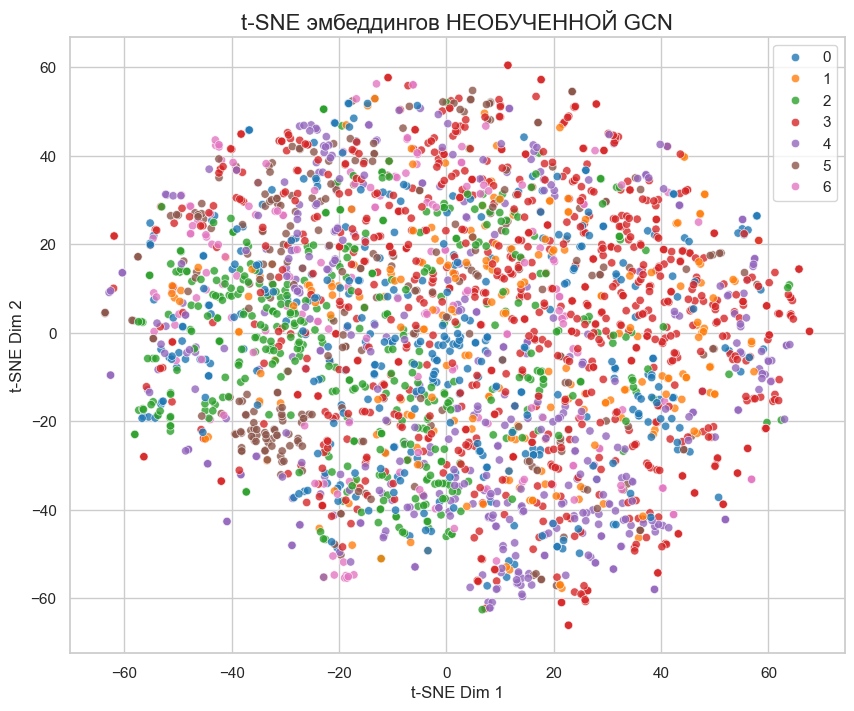

In [8]:
def visualize_embeddings(model: nn.Module, data, title: str):
    model.eval()
    with torch.no_grad():
        _, h = model(data.x, data.edge_index)
    
    tsne = TSNE(n_components=2, random_state=42)
    h_2d = tsne.fit_transform(h.cpu().numpy())
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=h_2d[:, 0], 
        y=h_2d[:, 1], 
        hue=data.y.cpu().numpy(), 
        palette="tab10", 
        legend="full", 
        alpha=0.8
    )
    plt.title(title, fontsize=16)
    plt.xlabel('t-SNE Dim 1')
    plt.ylabel('t-SNE Dim 2')
    plt.show()

untrained_gcn = GCNNodeClassifier(dataset.num_features, 16, dataset.num_classes)
visualize_embeddings(untrained_gcn, data, "t-SNE эмбеддингов НЕОБУЧЕННОЙ GCN")


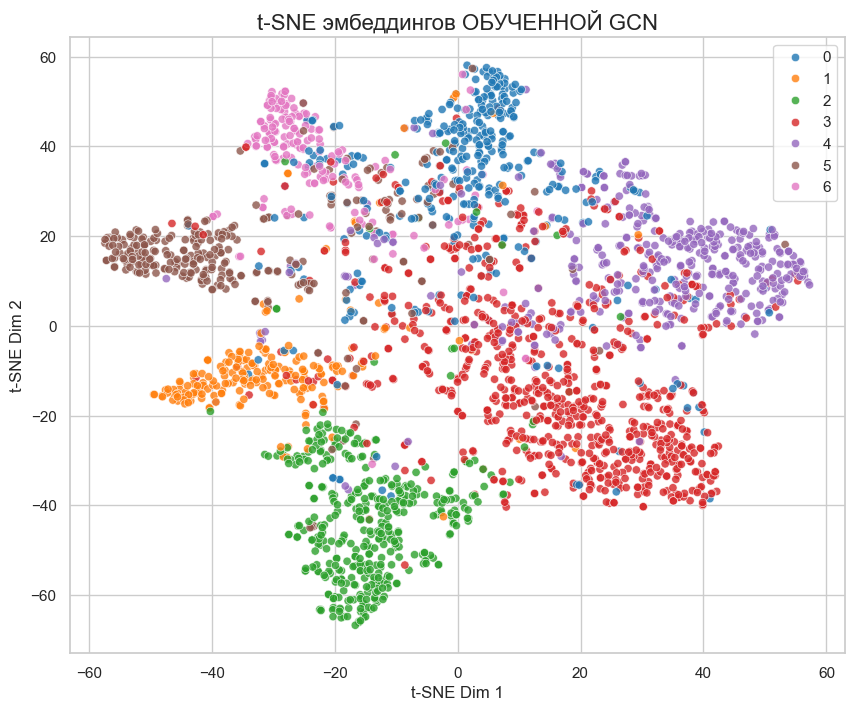

In [9]:

visualize_embeddings(gcn_model, data, "t-SNE эмбеддингов ОБУЧЕННОЙ GCN")

1. На графике необученной сети узлы разных классов перемешаны в хаотичное облако. 
   Сеть со случайными весами агрегирует признаки, но не извлекает полезного сигнала.

2. На графике обученной сети мы видим нечеткую кластеризацию. 
   Свойства модели позволили сети "разнести" классы в скрытом пространстве так, чтобы финальному 
   линейному слою было легко провести между ними разделяющие гиперплоскости.

<p class="task" id="4"></p>

4\.  Предыдущие решения не используют узлы, находящиеся в валидационном множестве. Решите задачу 2, используя валидационное множество для выполнения ранней остановки.

- [ ] Проверено на семинаре

In [11]:
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=50,
    verbose=True,
    mode='min'
)

gcn_model_es = GCNNodeClassifier(dataset.num_features, 16, dataset.num_classes)
pl_gcn_es = NodeClassifierPL(gcn_model_es)

trainer_gcn_es = pl.Trainer(
    max_epochs=2000,
    callbacks=[early_stop_callback],
    enable_progress_bar=False,
    enable_model_summary=False,
    logger=False
)

trainer_gcn_es.fit(pl_gcn_es, train_loader, val_loader)

print("\nОценка GCN (Early Stopping) на тестовой выборке:")
trainer_gcn_es.test(pl_gcn_es, test_loader, verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Metric val_loss improved. New best score: 1.920
Metric val_loss improved by 0.058 >= min_delta = 0.0. New best score: 1.863
Metric val_loss improved by 0.067 >= min_delta = 0.0. New best score: 1.796
Metric val_loss improved by 0.058 >= min_delta = 0.0. New best score: 1.739
Metric val_loss improved by 0.053 >= min_delta = 0.0. New best score: 1.685
Metric val_loss improved by 0.057 >= min_delta = 0.0. New best score: 1.629
Metric val_loss


Оценка GCN (Early Stopping) на тестовой выборке:


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8020000457763672     │
│         test_loss         │    0.6858230233192444     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.6858230233192444, 'test_acc': 0.8020000457763672}]

<p class="task" id="5"></p>

5\. Повторите решение задачи 4, сравнив несколько различных слоев:
* GCNConv
* SAGEConv (укажите `aggr="mean"`)
* GATConv (выберите для первого слоя `heads > 1`)

Выведите результат в виде таблицы:

| Модель    | Loss на обучении | Acc на обучении | Acc на тесте | Кол-во эпох до ранней остановки |
|-----------|------------------|-----------------|--------------|-------------|
| GraphConv |                  |                 |              |             |
| SAGEConv  |                  |                 |              |             |
| GATConv   |                  |                 |              |             |


- [ ] Проверено на семинаре

In [13]:
class SAGENodeClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = geom_nn.SAGEConv(in_channels, hidden_channels, aggr="mean")
        self.conv2 = geom_nn.SAGEConv(hidden_channels, out_channels, aggr="mean")

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        out = self.conv2(h, edge_index)
        return out, h

class GATNodeClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, heads: int = 8):
        super().__init__()

        self.conv1 = geom_nn.GATConv(in_channels, hidden_channels // heads, heads=heads)
        self.conv2 = geom_nn.GATConv(hidden_channels, out_channels, heads=1, concat=False)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        out = self.conv2(h, edge_index)
        return out, h


def train_and_evaluate(model_class, model_name: str, **kwargs) -> dict:
    model = model_class(dataset.num_features, 16, dataset.num_classes, **kwargs)
    pl_model = NodeClassifierPL(model)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=50, mode='min')
    
    trainer = pl.Trainer(
        max_epochs=500,
        callbacks=[early_stop],
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False
    )
    
    trainer.fit(pl_model, train_loader, val_loader)
    test_metrics = trainer.test(pl_model, test_loader, verbose=False)[0]
    
    model.eval()
    with torch.no_grad():
        logits, _ = model(data.x, data.edge_index)
        train_loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask]).item()
        train_preds = logits[data.train_mask].argmax(dim=-1)
        train_acc = (train_preds == data.y[data.train_mask]).float().mean().item()
    
    return {
        "Модель": model_name,
        "Loss на обучении": round(train_loss, 4),
        "Acc на обучении": round(train_acc, 4),
        "Acc на тесте": round(test_metrics['test_acc'], 4),
        "Кол-во эпох до ранней остановки": trainer.current_epoch
    }

results: List[Dict[str, Any]] =[]

print("Обучение GCN")
results.append(train_and_evaluate(GCNNodeClassifier, "GCNConv"))

print("Обучение GraphSAGE")
results.append(train_and_evaluate(SAGENodeClassifier, "SAGEConv"))

print("Обучение GAT")
results.append(train_and_evaluate(GATNodeClassifier, "GATConv", heads=8))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Обучение GCN


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Обучение GraphSAGE


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Обучение GAT


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [15]:
from IPython.display import Markdown

df_results = pd.DataFrame(results)
display(Markdown("\n" + df_results.to_markdown(index=False)))


| Модель   |   Loss на обучении |   Acc на обучении |   Acc на тесте |   Кол-во эпох до ранней остановки |
|:---------|-------------------:|------------------:|---------------:|----------------------------------:|
| GCNConv  |             0.0095 |                 1 |          0.797 |                                88 |
| SAGEConv |             0.001  |                 1 |          0.78  |                                71 |
| GATConv  |             0.0079 |                 1 |          0.773 |                                75 |